#### This notebook searches for the best model.

It contains the code to run the source extraction using TRAP on consecutive snapshot images (specifically used for ELAISN-1 images). Several combinations of scalars, models and model parameters are tested. The different combinations can be set in 'grid_test'. The best model is inspected and false positives are visualised.

In [1]:
import os
import trap
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import SkyCoord
import astropy.coordinates as coord
from astropy.stats import sigma_clip
import pandas as pd
import numpy as np
import random
import glob


In [2]:
# Settings to run the source association
surpress_duplications = True

# To keep things the same while working
random_state = None

In [3]:
# Change:
path = '/scratch/tswinkels/build_classification_model/'
# While name stays the same, no updates to save time.
name = 'DeBlend0'

Cataloguepath = path+'ELAIS_catalogue.fits'
pybdsf_cols = ['Source_id', 'Total_flux', 'E_Total_flux', 'RA', 'E_RA', 'DEC', 'E_DEC', 'S_Code']
DeepImagePath = '/scratch/antoniar/ELAIS-N1/ELAIS_deep-image-pb.fits'
ImagePath = '/scratch/antoniar/ELAIS-N1/deep_fields_individual_epochs/*.fits'

# Create rest of paths automatically
tomlPath = path+'trap_config_'+name+'.toml'
dbpath = path+name+'_db'


## CATALOGUE

In [4]:
# Open the catalog
with fits.open(Cataloguepath) as hdul:
    hdul.info()
    catalogue_table = Table(hdul[1].data)
    catalogue_wcs = WCS(hdul[1].header)

Filename: /scratch/tswinkels/build_classification_model/ELAIS_catalogue.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    235   154952R x 46C   [J, J, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 1A, K]   


In [5]:
# Match to expected trap output
catalogue = catalogue_table[pybdsf_cols].to_pandas()
catalogue = catalogue.rename(columns={"RA": "ra", "E_RA": "uncertainty_ew", "DEC": "dec", "E_DEC": "uncertainty_ns"})

print(catalogue.shape)
catalogue.head()

(154952, 8)


,Source_id,Total_flux,E_Total_flux,ra,uncertainty_ew,dec,uncertainty_ns,S_Code
0,0,0.000600,0.000146,247.727729,0.000139,54.923692,0.000210,S
1,1,0.000334,0.000147,247.709353,0.000158,54.771236,0.000390,S
2,2,0.001459,0.000154,247.704080,0.000099,54.776155,0.000044,S
3,3,0.000683,0.000238,247.715686,0.000394,54.858897,0.000186,S
4,4,0.001655,0.000114,247.695477,0.000042,54.710662,0.000036,S


## TRAP SOURCES

This section runs trap to extract candidates from the images.\
https://git.astron.nl/RD/trap

In [6]:
if not os.path.exists(dbpath):
    os.system("trap-run --config_file "+tomlPath+" -i '"+ImagePath+"' --nr_threads 4")

In [7]:
# Open the database
db_handle = trap.io.open_db("sqlite", dbpath)
with db_handle.connect() as conn:
    sources = pd.read_sql_query("SELECT * FROM extracted_sources", conn)
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

# Filter candidates
clean_sources = sources.groupby('src_id').filter(lambda item: not (item['is_duplicate'] == 1).any())
id_sources = clean_sources.groupby(['src_id']).first()

2026-02-05 13:34:06,400 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/DeBlend0_db' (io.py:296)


## ASSOCIATION

This method makes use of the source association of trap to associate the catalog with the found sources:\
https://git.astron.nl/RD/trap

In [8]:
from helperfunctions.associate import associate
"""
input:
sources,new_sources
output:
null_detection_ids: the ids corresponding to `new_sources.index` that were not found in sources
new_source_ids: the ids corresponding to `sources.index` that were in new_sources but not in the original sources
persistings_mapping: :class:`pd.DataFrame`: A dataframe containing the columns `[original_id, new_id, de_ruiter]` that map the indices
    from sources to new_sources of those that are identified as being a persistant source, 
    meaning it is a source that occurs in both sourcse lists.
duplicate_mapping: A dataframe containing the columns `[original_id, new_id, de_ruiter]` that map the indices 
    of any access sources in new_sources to the nearest source in the original sources DataFrame.
"""
null_detection_ids, new_source_ids, persistings_mapping, duplicate_mapping = associate(catalogue, id_sources, surpress_duplications=False)

In [9]:
# Create dataframes that contain same sources per index
matched_catalogue = catalogue.loc[persistings_mapping['original_id'].values].reset_index(drop=True)
matched_sources = id_sources.loc[persistings_mapping['new_id'].values].reset_index()
matched_sources.head()

,src_id,id,ra,dec,ra_fit_err,dec_fit_err,peak_flux,peak_flux_err,int_flux,int_flux_err,...,reduced_chisq,ns_sys_err,ew_sys_err,gaussian_fit,uncertainty_ew,uncertainty_ns,im_id,is_force_fit,is_duplicate,parent
0,0,0,244.196031,55.025001,0.000152,0.000087,0.000902,0.000070,0.000902,0.000131,...,6.663707,0.0,0.0,1,0.000123,0.000123,0,0,0,-1
1,1,1,244.190511,55.042292,0.000040,0.000023,0.006322,0.000070,0.006322,0.000217,...,10903.094727,0.0,0.0,1,0.000033,0.000033,0,0,0,-1
2,3,3,244.174846,54.938558,0.000109,0.000062,0.001777,0.000082,0.001777,0.000177,...,17.334593,0.0,0.0,1,0.000088,0.000088,0,0,0,-1
3,4,4,244.176137,54.973847,0.000094,0.000054,0.002390,0.000089,0.002390,0.000203,...,5.683568,0.0,0.0,1,0.000077,0.000077,0,0,0,-1
4,5,5,244.167025,54.900110,0.000179,0.000103,0.000806,0.000082,0.000806,0.000143,...,20.714401,0.0,0.0,1,0.000145,0.000145,0,0,0,-1


In [10]:
matched_catalogue.head()

,Source_id,Total_flux,E_Total_flux,ra,uncertainty_ew,dec,uncertainty_ns,S_Code
0,44203,0.000664,0.000019,244.195741,0.000012,55.024827,0.000011,S
1,44261,0.014726,0.000099,244.190273,0.000002,55.042191,0.000005,M
2,44570,0.001771,0.000050,244.174400,0.000008,54.938523,0.000009,M
3,44571,0.001909,0.000024,244.175902,0.000005,54.973729,0.000005,S
4,44742,0.000745,0.000022,244.166660,0.000013,54.899965,0.000012,S


In [11]:
# Remove sources labeld other then S or M
if len(pd.unique(matched_catalogue.get('S_Code', ''))) > 2:
    mask = matched_catalogue.get('S_Code', '').isin(['S','M'])
    matched_catalogue = matched_catalogue[mask]
    matched_sources = matched_sources[mask]

print(matched_catalogue['S_Code'].value_counts())

S_Code
S    1066
M     590
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Functions to visualise if the source association worked
def scatter_catalogue(ax, catalogue, wcs, size, color, title, label):
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    ax.set_xlim((241,242))
    ax.set_ylim((54,54.5))
    
    x, y = wcs.world_to_pixel_values(catalogue['ra'],catalogue['dec'])
    ax.scatter(
        x, y,
        s=size,
        c=color,
        alpha=0.6,
        label=label)

def draw_match_lines(ax, cat1, cat2, wcs, color="gray", alpha=0.3, lw=0.7):
    x1, y1 = wcs.world_to_pixel_values(cat1['ra'], cat1['dec'])
    x2, y2 = wcs.world_to_pixel_values(cat2['ra'], cat2['dec'])
    
    for i in range(len(cat1)):
        inside1 = 242 <= x1[i] <= 243 and 54.90 <= y1[i] <= 55.10
        inside2 = 242 <= x2[i] <= 243 and 54.90 <= y2[i] <= 55.10
        
        if inside1 or inside2:
            ax.plot(
                [x1[i], x2[i]],
                [y1[i], y2[i]],
                color=color,
                alpha=alpha,
                linewidth=lw
            )

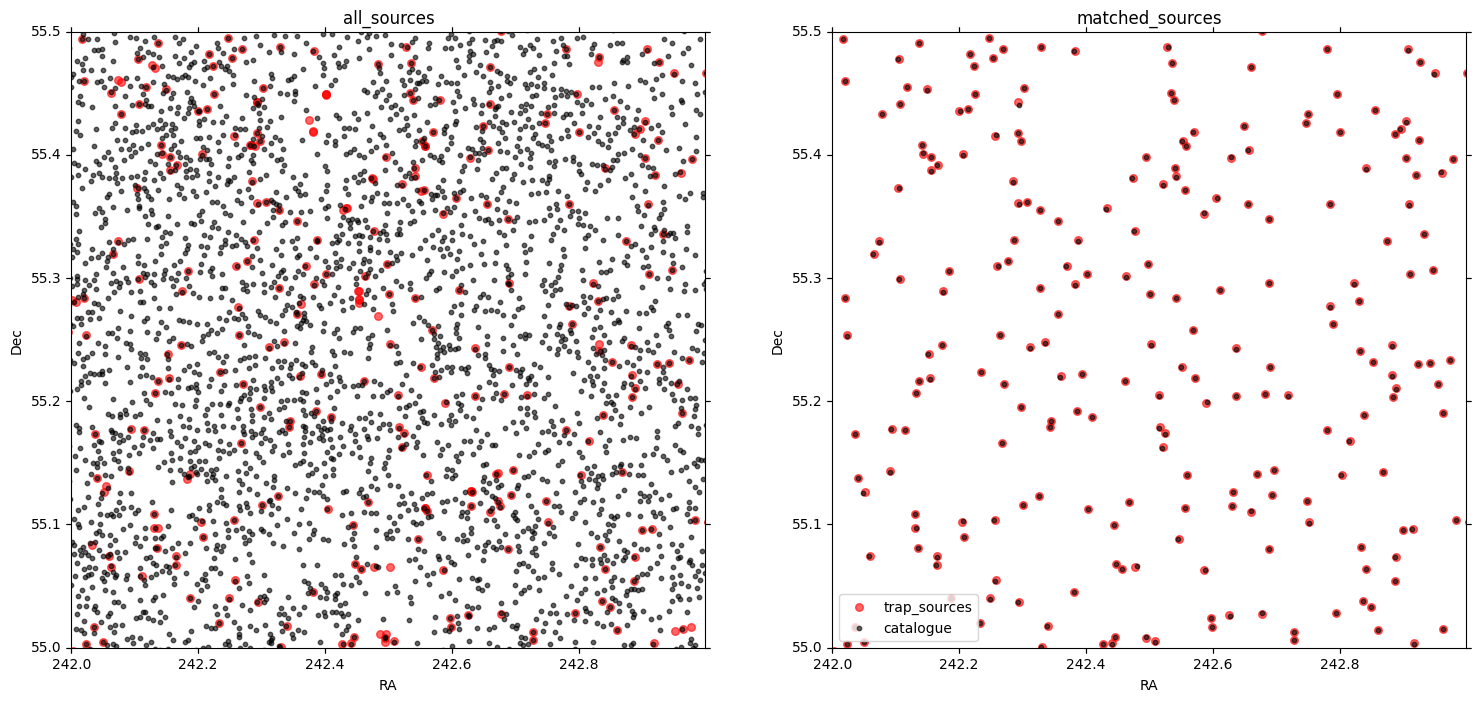

In [13]:
# Visual inspection of the source association
fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': catalogue_wcs}) 

scatter_catalogue(axes[0], id_sources, catalogue_wcs, 30, "r", "all_sources", "trap_sources" ) 
scatter_catalogue(axes[0], catalogue, catalogue_wcs, 10, "k", "all_sources", "catalogue") 

scatter_catalogue(axes[1], matched_sources, catalogue_wcs, 30, "r", "matched_sources", "trap_sources" ) 
scatter_catalogue(axes[1], matched_catalogue, catalogue_wcs, 10, "k", "matched_sources", "catalogue") 

draw_match_lines(axes[1], matched_catalogue, matched_sources, catalogue_wcs)

plt.legend()
plt.show()


## COMPARE MODELS

This section searches for the best model (this is just a test and certainly not final).

In [19]:
import pandas as pd 
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 
# Models 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC, LinearSVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.metrics import make_scorer, precision_score

def test_combinations(X_train, y_train, random_state=None):

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    param_distributions = [

        # ---- Logistic Regression ----
        {
            'scaler': [StandardScaler(), RobustScaler()],
            'clf': [LogisticRegression(max_iter=2000, solver='lbfgs')],
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__class_weight': [None, 'balanced'],
        },

        # ---- Linear SVM ----
        {
            'scaler': [StandardScaler()],
            'clf': [LinearSVC(max_iter=5000)],
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__class_weight': [None, 'balanced'],
        },

        # ---- RBF SVM ----
        {
            'scaler': [StandardScaler()],
            'clf': [SVC()],
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 0.1, 0.01],
            'clf__class_weight': [None, 'balanced'],
        },
    ]

    precision_M = make_scorer(
        precision_score,
        pos_label="M",
        zero_division=0
    )
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=40,
        scoring=precision_M,
        n_jobs=10,
        cv=cv,
        random_state=random_state,
        verbose=1
    )

    search.fit(X_train, y_train)
    results = pd.DataFrame(search.cv_results_).sort_values('mean_test_score', ascending=False)
    best_model = search.best_estimator_

    return search, results, best_model


In [20]:
from sklearn.model_selection import train_test_split
# from helperfunctions.Grid_Search import test_combinations

# Clean and split the data
X = matched_sources.copy()
X = X.drop(columns=["ra", "uncertainty_ew", "dec", "uncertainty_ns", "src_id", "id", "parent", "im_id"])
X_train, X_test, y_train, y_test = train_test_split(X, matched_catalogue['S_Code'], test_size=0.2, random_state=random_state)

# Check combinations to find the best model and save it
search, results, best_model = test_combinations(X_train, y_train, random_state=random_state)
scaler = best_model['scaler']
model = best_model['clf']

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/tswinkels/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/tswinkels/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
# Print some information about the model
print(f'{results.shape[0]} combinations tested \n Best model: \n')
print(best_model)

print("Best CV score:", search.best_score_)
print("Best params:")
print(search.best_params_)

In [ ]:
# Run the model on the test data and store the results
results = pd.DataFrame({
    "Prob_M": best_model.predict_proba(X_test)[:, list(model.classes_).index('M')],
    "Predicted_Label": best_model.predict(X_test),
    "True_Label": y_test.values},
    index=X_test.index)

# Print the test results
print("\nTest set classification report:")
print(classification_report(y_test, results['Predicted_Label']))

print("Test ROC AUC:", roc_auc_score(y_test, results['Prob_M']))

In [ ]:
# Split correct and incorrect predictions
correct = results[results["True_Label"] == results["Predicted_Label"]]
correct_s = correct[correct["True_Label"] == 'S']
correct_m = correct[correct["True_Label"] == 'M']

wrong = results[results["True_Label"] != results["Predicted_Label"]]
wrong_true_s = wrong[wrong["True_Label"] == 'S']
wrong_true_m = wrong[wrong["True_Label"] == 'M']

# Plot a visualisation of the performance of the model
plt.figure(figsize=(9, 6))

plt.scatter(correct_s['Prob_M'], correct_s.index, c="green", marker='*', alpha=0.7,
            label="True negative")
plt.scatter(correct_m['Prob_M'], correct_m.index, c="green", alpha=0.7,
            label="True positive")

plt.scatter(wrong_true_s['Prob_M'], wrong_true_s.index, c="red", marker='*', alpha=0.9,
            label="False positive")
plt.scatter(wrong_true_m['Prob_M'], wrong_true_m.index, c="red", alpha=0.9,
            label="False negative")

plt.xlabel("Probability of being EXTENDED (M)")
plt.xlim(0,1)
plt.ylabel("Sample index (display order)")
plt.title(f"Prediction Confidence, {type(scaler).__name__, type(model).__name__}")
plt.legend()
plt.tight_layout()
plt.show()


## Visualise false positives

This section visualises false positives. By inspecting the sources that are classified as extended but are actually compact, we can try to see why the model is not working.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd


# -----------------------------------------------------------------------------
# Plotting utilities
# -----------------------------------------------------------------------------

def plot_image_with_colorbar(data, ax, fig,
                             title="LoTSS DR2 low res",
                             vmin=-0.05, vmax=5):
    """
    Display image data on a WCS axis and attach a horizontal colorbar.
    """
    im = ax.imshow(
        data,
        origin="lower",
        cmap="gray_r",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title, fontsize=18)

    # Dedicated colorbar axis
    cax = fig.add_axes([0.52, 0.0, 0.43, 0.05])
    cax.tick_params(labelsize=14)

    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.set_label("Flux density (mJy/beam)", fontsize=14)

    return im


def set_zoom(ax, ra, dec, wcs, pixel_radius):
    """
    Zoom axis to a square region centered on (ra, dec).
    """
    px, py = wcs.wcs_world2pix(ra, dec, 1)
    ax.set_xlim(px - pixel_radius, px + pixel_radius)
    ax.set_ylim(py - pixel_radius, py + pixel_radius)


def format_wcs_axes(ax):
    """
    Apply consistent formatting to WCS axes.
    """
    ax.set_xlabel("RA (J2000)", fontsize=14)
    ax.set_ylabel("DEC (J2000)", fontsize=14)

    ax.coords[0].set_ticklabel(size=14)
    ax.coords[1].set_ticklabel(size=14)

    ax.coords[0].set_ticks_position("b")
    ax.coords[1].set_ticks_position("l")

    ax.coords[0].set_ticks(size=6)
    ax.coords[1].set_ticks(size=6)

def pixel_bounds_from_sources(wcs, ra, dec, padding_frac=0.15):
    """
    Compute pixel bounds enclosing all sky positions.
    """
    ra = np.asarray(ra)
    dec = np.asarray(dec)

    x, y = wcs.wcs_world2pix(ra, dec, 1)

    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    dx = xmax - xmin
    dy = ymax - ymin

    # Handle single-source edge case
    if dx == 0:
        dx = 50
    if dy == 0:
        dy = 50

    xmin -= dx * padding_frac
    xmax += dx * padding_frac
    ymin -= dy * padding_frac
    ymax += dy * padding_frac

    return xmin, xmax, ymin, ymax
    
# -----------------------------------------------------------------------------
# Main plotting function
# -----------------------------------------------------------------------------

def plot_lotss_cutout(image_full, wcs, center_source, title=None, zoom=None):
    """
    Plot a LoTSS image cutout centered on a given source, optionally
    overplotting nearby catalogue sources.
    """
    # Convert Jy -> mJy
    image_full = image_full * 1000

    # Figure & axis
    fig = plt.figure(figsize=(10, 6))
    gs = gridspec.GridSpec(
        nrows=1, ncols=1,
        left=0.05, right=0.95,
        bottom=0.20, top=0.95
    )
    ax = fig.add_subplot(gs[0], projection=wcs)

    plot_image_with_colorbar(image_full, ax, fig, title)

    # Central source marker
    ax.scatter(
        center_source["ra"],
        center_source["dec"],
        transform=ax.get_transform("fk5"),
        facecolor="none",
        edgecolor="red",
        s=500,
        linewidth=2,
    )
    ax.scatter(
        [],
        [],
        marker="o",
        c="red",
        label=f"Center source: {center_source['int_flux'] * 1000:.0f} mJy",
    )
    ax.legend(fontsize=14, loc=(1.1, 0.1))

    # Zoom if requested
    if zoom is not None:
        set_zoom(
            ax,
            center_source["ra"],
            center_source["dec"],
            wcs,
            pixel_radius=zoom,
        )

    format_wcs_axes(ax)
    plt.show()


# -----------------------------------------------------------------------------
# Visual inspection driver
# -----------------------------------------------------------------------------

def visual_inspection(path_to_image, sources_to_inspect, matched_sources, matched_catalogue):
    """
    Loop over candidate sources and generate inspection plots.
    """
    with fits.open(path_to_image) as hdul:
        deep_image_data = hdul[0].data
        image_full = np.squeeze(deep_image_data)
        deep_wcs = WCS(hdul[0].header, naxis=2)

    matched_sources = matched_sources.loc[sources_to_inspect.index.values] 
    
    zoom_pixels = 200
    match_radius_deg = 2/60
    min_flux_mjy = 1

    for idx, source in matched_sources.iterrows():
        print(idx)
        print("\n trap position: ", source["ra"], source["dec"],'\n catalogue position: ',matched_catalogue.loc[idx]["ra"], matched_catalogue.loc[idx]["dec"])
        plot_lotss_cutout(
            image_full=image_full,
            wcs=deep_wcs,
            center_source=source,
            title=f"Predicted label: {sources_to_inspect.loc[idx]['Predicted_Label'], round(sources_to_inspect.loc[idx]['Prob_M'],2)}, Correct label: {sources_to_inspect.loc[idx]['True_Label']}",
            zoom=zoom_pixels,
        )
  
def plot_all_sources(path_to_image, sources_to_inspect, title):
    """
    Plot a single LoTSS image containing all sources_to_inspect,
    with correctly scaled bounds.
    """
    with fits.open(path_to_image) as hdul:
        deep_image_data = hdul[0].data
        image_full = np.squeeze(deep_image_data)
        deep_wcs = WCS(hdul[0].header, naxis=2)
    
    # Convert Jy -> mJy
    image_full = image_full * 1000

    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(
        nrows=1, ncols=1,
        left=0.05, right=0.95,
        bottom=0.20, top=0.95
    )
    ny, nx = image_full.shape
    
    ax = fig.add_subplot(gs[0], projection=deep_wcs)
    
    ax.set_xlim(-0.5, nx - 0.5)
    ax.set_ylim(-0.5, ny - 0.5)

    # VERY IMPORTANT: prevent autoscaling
    ax.set_autoscale_on(False)

    # --- Now draw image ---
    plot_image_with_colorbar(image_full, ax, fig, title)

    # Plot all sources
    ax.scatter(
        sources_to_inspect["ra"],
        sources_to_inspect["dec"],
        transform=ax.get_transform("fk5"),
        facecolor="none",
        edgecolor="red",
        s=300,
        linewidth=2,
        label="Sources to inspect",
    )

    format_wcs_axes(ax)
    ax.legend(fontsize=14)

    plt.show()

In [ ]:
plot_all_sources(DeepImagePath, matched_sources.loc[wrong_true_s.index.values], 'False positives (S)')

correct
correct_s
correct_m
wrong
wrong_true_s
wrong_true_m


In [ ]:
visual_inspection(DeepImagePath, wrong_true_s, matched_sources, matched_catalogue)

In [ ]:
visual_inspection(DeepImagePath, correct_m, matched_sources, matched_catalogue)